In [4]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml
import torch
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu

from train_mod_cog import RNNModel

device = eg_utils.get_device()

def add_one_hot_encoding(inputs):
    task_rules = inputs[:,:,-1]
    one_hot_rule_inputs = torch.nn.functional.one_hot(task_rules.long(), num_classes=82).float()
    inputs = torch.cat([inputs[:,:,:-1], one_hot_rule_inputs], dim=-1)
    return inputs

In [3]:
%load_ext autoreload
%autoreload 2

# Defining folders with experiments 

In [4]:
# load data
# data_dir = Path(os.path.join(os.environ['SCRATCH'], "eg_paper/mod_cog_data_v2"))
data_dir = Path('/network/projects/_groups/linclab_users/eg/modcog/data_v2')
print(os.listdir(data_dir)[:])

@dataclass
class ModelConfig:
    hidden_size: int = 2500

@dataclass
class Config:
    model: ModelConfig = ModelConfig()
    batch_size: int = 512
    seq_len:int = 350
    update_alg: str = "gd"
    copy_data_to_device_mem: bool = False
    num_workers: int = 0
    pin_memory: bool = True

cfg = Config()
loaders = au.get_dataloaders(cfg)

['mod_cog_test.npz', 'mod_cog_test_x.memmap', 'mod_cog_test_y.memmap', 'mod_cog_train.npz', 'mod_cog_train_x.memmap', 'mod_cog_train_y.memmap', 'mod_cog_val.npz', 'mod_cog_val_x.memmap', 'mod_cog_val_y.memmap', 'slurm-4893722.out']
Using data from scratch directory
Loading train memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2
Loading val memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2
Loading test memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2


In [5]:
def get_results_dict(results_dir):
    # drop larger weights for now, comparing 1e-7 eg, 1e-6 gd
    exp_names = []
    for exp_name in os.listdir(results_dir):
        if exp_name.startswith("eg"):
            if "1e-07" in exp_name:exp_names.append(exp_name)
        elif exp_name.startswith("gd"):
            if "1e-06" in exp_name:exp_names.append(exp_name)
    #print(exp_names)
    # reformat exp_name for use as a key
    exp_folders = au.DotDict({au.format_exp_as_key(f):results_dir/f for f in exp_names})
    results_dict = au.load_results(exp_folders)
    return results_dict

In [6]:
# Grab pretrained model checkpoints
scratch = Path('/network/projects/_groups/linclab_users/eg/modcog')
results_dir = scratch/"exp8_final_combined"
results_dict = get_results_dict(results_dir)
print("Results loaded", results_dict.keys())

Results loaded dict_keys(['eg_log_normal', 'eg_normal', 'eg_uniform', 'gd_log_normal', 'gd_normal', 'gd_uniform'])


In [7]:
results_dict.eg_log_normal.c = "#f05039" 
results_dict.gd_log_normal.c = "#1f449c" 

In [8]:
gd_exps_dict = results_dict.gd_log_normal 
eg_exps_dict = results_dict.eg_log_normal

n_seeds = 5 # n experiments out of 5 total to run
gd_exp_list = [d for k,d in gd_exps_dict.items() if k.startswith("seed")]
eg_exp_list = [d for k,d in eg_exps_dict.items() if k.startswith("seed")]
all_exps_list = gd_exp_list[:n_seeds] + eg_exp_list[:n_seeds]

In [9]:
seed_idx = 0
gd_model = au.get_modelv2(gd_exp_list[seed_idx].cfg)
eg_model = au.get_modelv2(eg_exp_list[seed_idx].cfg)

print(eg_model)
print(gd_model)

Setting split bias
RNNModelV2(
  (rnn): SplitBiasRNNCell(
    (base_layer): RNNCell(115, 2500, nonlinearity=relu)
  )
  (fc): SplitBias(
    (base_layer): Linear(in_features=2500, out_features=17, bias=True)
  )
)
RNNModelV2(
  (rnn): RNNCell(115, 2500, nonlinearity=relu)
  (fc): Linear(in_features=2500, out_features=17, bias=True)
)


In [90]:
# check epoch ckpts are sorted (they are in analysis_utils)
gd_exp_list[seed_idx].epoch_ckpts

[PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/epoch_ckpts/model_0.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/epoch_ckpts/model_1.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/epoch_ckpts/model_2.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/epoch_ckpts/model_3.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/epoch_ckpts/model_4.pt'),
 PosixPath('/ne

In [32]:
gd_model = au.load_ckpt(gd_model, gd_exp_list[seed_idx].epoch_ckpts[-1])
eg_model = au.load_ckpt(eg_model, eg_exp_list[seed_idx].epoch_ckpts[-1])

In [13]:
def get_subtasks_and_activities(model, loader, device, n_subtasks=82, debug=False, return_activations=True):
    """
    Modfidied version of func from analysis of solution order, returns acitvations
    if debug, breaks early. 
    """
    task_rule_labels = torch.from_numpy(np.arange(n_subtasks)).to(device)
    task_wise_accs = []
    task_wise_proportions = []
    dec_accs = []
    batch_activations = {}
    model = model.to(device)
    all_labels = []
    for i, (inputs, labels) in enumerate(loader):
        print(f"{i}/{len(loader)}", end="\r")
#         all_labels.append(labels)
        inputs, labels = inputs.to(device), labels.to(device)
        input_subtask_labels = inputs[:,:,-1].clone() # store the tensor of non one hot encoded task labels 
#         print(input_subtask_labels.shape)
#         print(input_subtask_labels)
        inputs = add_one_hot_encoding(inputs).to(device)
        labels = labels.to(device).long()
        
        outputs, activations = model(inputs, return_acts=True)
        choices = torch.argmax(outputs, dim=-1)
        #batch_activations[i] = activations.detach().cpu().numpy()
        
        dec_mask = inputs[:,:,0] == 0 # fixation/decision period mask, fix=1, dec=0
        labels_for_full_acc = 1 + labels
        labels_for_full_acc[~dec_mask] = 0

        acc = torch.eq(choices, labels_for_full_acc).type(torch.float32).mean().item()
        #dec_acc = torch.eq(choices[dec_mask], labels_for_full_acc[dec_mask]).type(torch.float32).mean().item()

#         print(labels_for_full_acc[dec_mask].shape)
#         print(labels_for_full_acc[dec_mask])
        dec_correct_choices = torch.eq(choices[dec_mask],labels_for_full_acc[dec_mask]).type(torch.float32)
        dec_acc = dec_correct_choices.mean()
        dec_accs.append(dec_acc.item())
        #print(acc, dec_accs)

        subtask_labels_dec_period = input_subtask_labels[dec_mask]
        subtask_labels_bool_array = task_rule_labels[:, None] == subtask_labels_dec_period[None,:]
        # this creates a bool array of shape (n_subtasks, batch_size*seq_len) 
        # each row is a bool array of subtask label == task_label (over all time steps and batch examples)
        
        # broadcast the dec period correct choices array over and mult by subtasks_bool_array
        task_wise_dec_correct_choices = subtask_labels_bool_array*dec_correct_choices[None,:]

        total_taskwise_examples = subtask_labels_bool_array.sum(axis=1)
        total_taskwise_correct = task_wise_dec_correct_choices.sum(axis=1)
        
        task_wise_acc = total_taskwise_correct/total_taskwise_examples
        task_wise_accs.append(task_wise_acc)

        # also store the relative proportion of each task for taking a weighted average
        # to confirm code results in the same overall accuracy as dec acc
        task_wise_proportion = total_taskwise_examples/total_taskwise_examples.sum()
        task_wise_proportions.append(task_wise_proportion)
        
        if debug and i == 3: break
        
    print(np.mean(dec_accs), "is mean dec acc")
    # stack the task_wise lists into n_subtasks x n_batches
    task_wise_accs = torch.stack(task_wise_accs, dim=1)
    task_wise_proportions = torch.stack(task_wise_proportions, dim=1)
#     all_labels = torch.stack(all_labels)

    task_wise_accs = task_wise_accs.mean(dim=1) 
    task_wise_proportions = task_wise_proportions.mean(dim=1)
    assert np.allclose((task_wise_accs@task_wise_proportions).detach().cpu().numpy(), np.mean(dec_accs), atol=1e-3)

    if return_activations:
        return task_wise_accs, task_wise_proportions, activations, all_labels #batch_activations
    return task_wise_accs, task_wise_proportions, all_labels


In [35]:
# run with dubg
gd_task_wise_accs, gd_task_wise_proportions, gd_acts, gd_labels = \
    get_subtasks_and_activities(gd_model, loaders["val"], device, debug=True)

0.9840732961893082 is mean dec acc


In [36]:
gd_acts.shape # bs x seq len x n hidden

torch.Size([512, 350, 2500])

In [37]:
eg_task_wise_accs, eg_task_wise_proportions, eg_acts, eg_labels = get_subtasks_and_activities(eg_model, loaders["val"], device, debug=True)

0.9835217595100403 is mean dec acc


# Data loading done

In [38]:
eg_acts.shape

torch.Size([512, 350, 2500])

In [39]:
gd_acts.view(-1, 2500).shape

torch.Size([179200, 2500])

In [40]:
gd_acts_flat = gd_acts.view(-1, 2500)
eg_acts_flat = eg_acts.view(-1, 2500)


In [41]:
import scipy.stats as stats
n_samples = 10000
data_inds = np.random.permutation(eg_acts_flat.shape[0])[:n_samples]

gd_act_np = gd_acts_flat[data_inds].flatten().detach().numpy()
eg_act_np = eg_acts_flat[data_inds].flatten().detach().numpy()


print(stats.kurtosis(gd_act_np.flatten()), stats.kurtosis(eg_act_np.flatten()))
print(stats.skew(gd_act_np.flatten()), stats.skew(eg_act_np.flatten()))

23.81171033450466 48.49046678365124
4.351134737747289 5.238578410052672


In [42]:
n_samples = 10000
data_inds = np.random.permutation(eg_acts_flat.shape[0])[:n_samples]

In [43]:
from alpha import alpha, rankme, utils

In [44]:
gd_metric_alpha = alpha.get_alpha(gd_acts_flat[data_inds], fit_range=np.arange(3,30))

In [45]:
gd_metric_alpha

(0.6414247603243027,
 array([0.07783844, 0.04990063, 0.03847306, ..., 0.00058546, 0.00058528,
        0.00058509]),
 -0.9813483780559724,
 0.47848396909643043)

In [46]:
eg_metric_alpha = alpha.get_alpha(eg_acts_flat[data_inds],  fit_range=np.arange(3,30))

In [47]:
eg_metric_alpha

(0.7601256887364918,
 array([0.10385042, 0.06131795, 0.04505429, ..., 0.00031601, 0.00031589,
        0.00031578]),
 -0.27646573003226815,
 0.7549194416152345)

In [48]:
eg_metric_rankme = rankme.get_rankme(eg_acts_flat[data_inds])
eg_metric_rankme

169.12517

In [49]:
gd_metric_rankme = rankme.get_rankme(gd_acts_flat[data_inds])
gd_metric_rankme

157.70177

In [50]:
gd_eigenspec = utils.get_eigenspectrum(gd_acts_flat[data_inds])

In [51]:
eg_eigenspec = utils.get_eigenspectrum(eg_acts_flat[data_inds])

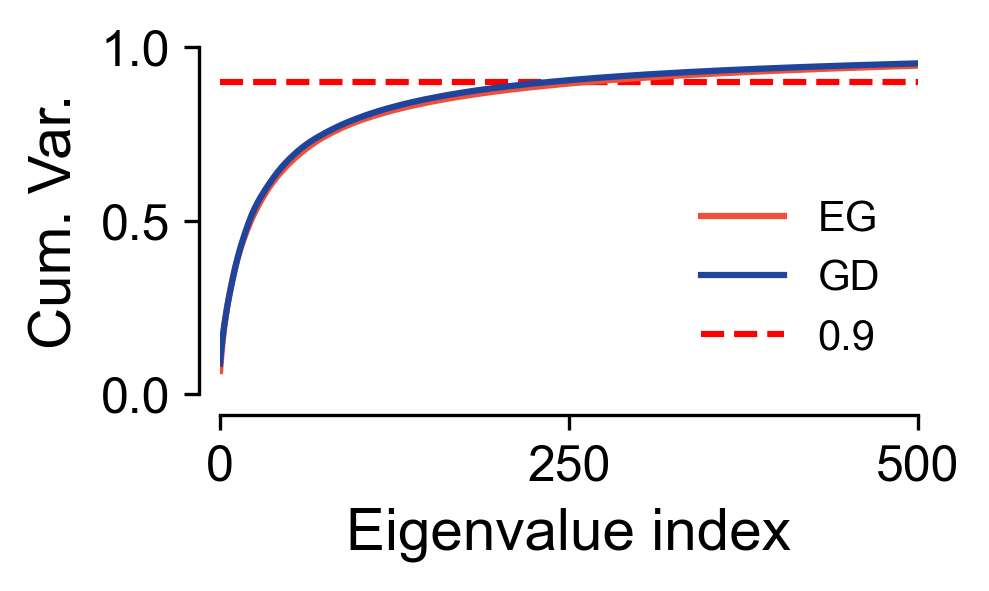

In [52]:
plt.figure(figsize=(3,1.5), dpi=300 )
plt.plot(np.cumsum(eg_eigenspec), eg_exps_dict.c, label="EG")
plt.plot(np.cumsum(gd_eigenspec), gd_exps_dict.c, label = "GD")
plt.hlines(0.9, xmin=0, xmax=5000, color="r", linestyles="--", label="0.9", zorder=0)

plt.xlim(0, 500)
plt.ylim(0,1)
num_xticks = 3
num_yticks = 3
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
x_ticks = np.linspace(xmin, xmax, num_xticks)
y_ticks = np.linspace(ymin, ymax, num_yticks)
plt.xticks(x_ticks)
plt.ylabel("Cum. Var.")
plt.xlabel("Eigenvalue index")

# legend_patches = []
# legend_patches.append(patches.Rectangle((0,0), 1, 1, facecolor="g", label="EG"))
# legend_patches.append(patches.Rectangle((0,0), 1, 1, facecolor="k", label="GD"))
#plt.legend(legend_patches, ["EG", "GD"], handler_map=leg_handler_map, frameon=False, loc=0)
plt.legend(frameon=False)

sns.despine(offset=5, trim=True)

(0.001, 0.14261652473026665)

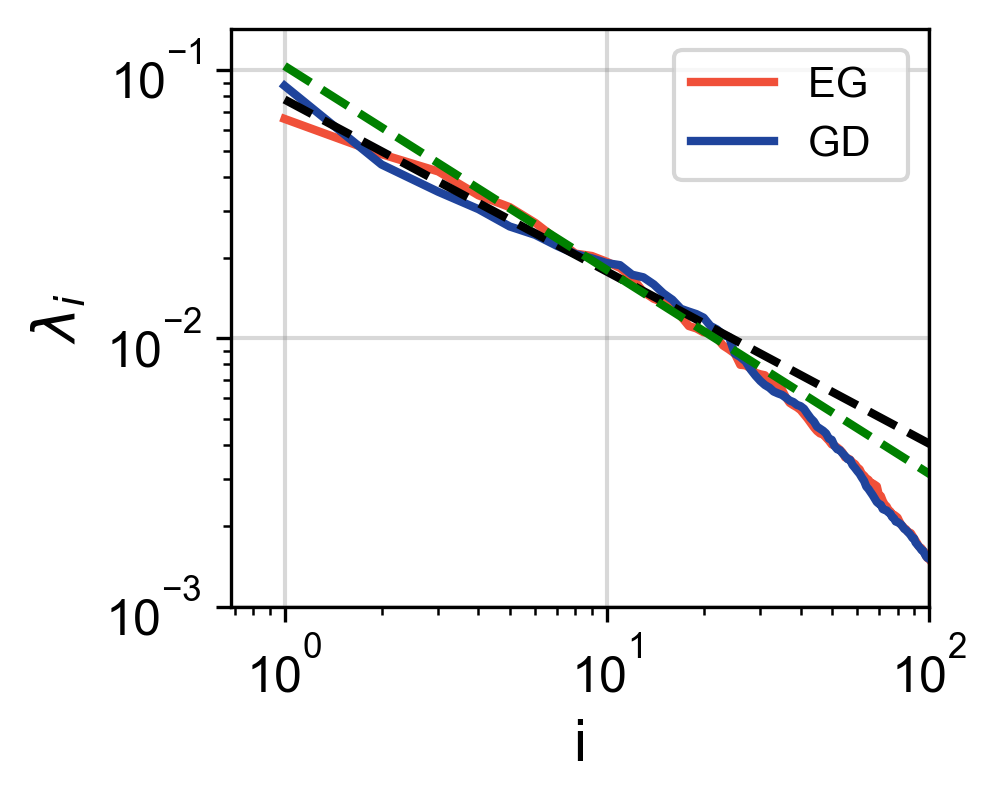

In [53]:
plt.figure(figsize=(3,2.5), dpi=300 )
xrange = np.arange(1, 1 + len(eg_eigenspec))
plt.loglog(xrange, eg_eigenspec, c=eg_exps_dict.c, ls='-', lw=2.0, label='EG  ')

xrange = np.arange(1, 1 + len(gd_eigenspec))
plt.loglog(xrange, gd_eigenspec, c=gd_exps_dict.c, ls='-', lw=2.0, label='GD ')

xlim_max = 1024 if len(gd_eigenspec) > 512 else len(gd_eigenspec) - 20

plt.xlim(right=xlim_max)
plt.ylim(bottom=1e-4)
plt.legend()
plt.grid(True, color='gray', lw=1.0, alpha=0.3)
plt.xlabel('i')
plt.ylabel(r'$\lambda_i$')

_, ypred, r2, r2_100 = gd_metric_alpha
xrange = np.arange(1, 1 + len(ypred))
plt.loglog(xrange, ypred, c='k', ls='--', lw=2.0, label='Powerlaw fit')
    # plt.title(
    #     rf'Eigenspectrum and powerlaw fit, $\alpha$ = {alpha:.3f} '
    #     + rf'(r2_100 = {r2_100:.3f})'
    # )

_, ypred, r2, r2_100 = eg_metric_alpha
xrange = np.arange(1, 1 + len(ypred))
plt.loglog(xrange, ypred, c='g', ls='--', lw=2.0, label='Powerlaw fit')
    # plt.title(
    #     rf'Eigenspectrum and powerlaw fit, $\alpha$ = {alpha:.3f} '
    #     + rf'(r2_100 = {r2_100:.3f})'
    # )


plt.xlim(right=100)
plt.ylim(bottom=1e-3)



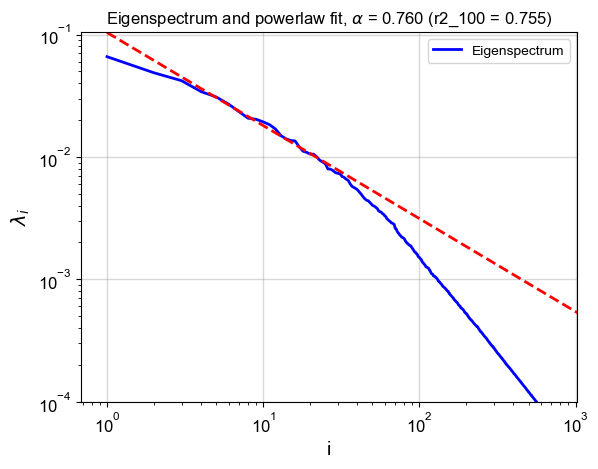

In [54]:
alpha.plot_powerlaw(eg_eigenspec, eg_metric_alpha)

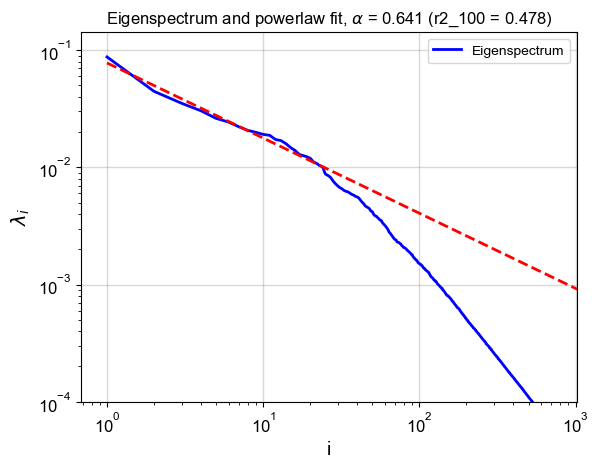

In [55]:
alpha.plot_powerlaw(gd_eigenspec, gd_metric_alpha)

# Loading all seeds

In [28]:
# run with dubg
n_samples = 1000
gd_all_acts = np.zeros((5, n_samples, 2500))
eg_all_acts = np.zeros((5, n_samples, 2500))
data_inds = np.random.permutation(512 * 350)[:n_samples]

for seed in range(5):
    gd_model = au.get_modelv2(gd_exp_list[seed].cfg)
    eg_model = au.get_modelv2(eg_exp_list[seed].cfg)

    gd_model = au.load_ckpt(gd_model, gd_exp_list[seed].epoch_ckpts[-1])
    eg_model = au.load_ckpt(eg_model, eg_exp_list[seed].epoch_ckpts[-1])

    _, _, gd_acts, _ = \
        get_subtasks_and_activities(gd_model, loaders["val"], device, debug=True)

    _, _, eg_acts, _ = \
        get_subtasks_and_activities(eg_model, loaders["val"], device, debug=True)
    
    gd_all_acts[seed] = gd_acts.reshape((-1, 2500))[data_inds]
    eg_all_acts[seed] = eg_acts.reshape((-1, 2500))[data_inds]

Setting split bias
0.9840732961893082 is mean dec acc
0.9835217595100403 is mean dec acc
Setting split bias
0.9838567525148392 is mean dec acc
0.9841100871562958 is mean dec acc
Setting split bias
0.9842540621757507 is mean dec acc
0.9844043552875519 is mean dec acc
Setting split bias
0.9835304468870163 is mean dec acc
0.9841334968805313 is mean dec acc
Setting split bias
0.9839699417352676 is mean dec acc
0.9841504693031311 is mean dec acc


In [16]:
from scipy.stats import norm

def get_norm_pdf(points, mean, std):
    return norm(loc=mean, scale=std).pdf(points)

def get_checkpoint_name(results, seed, epoch_idx):
    return str(results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt'


def plot_act_hists(eg_arr, gd_arr, eg_key="rnn.base_layer.weight_hh",
                      zero_th=None, log_weights=False, log_y_scale=False, kde=False, stat='proportion',
                     gaussian_approx=False, seperate_plots=True, xlims_step=None, 
                      eg_color='g', gd_color='b'):
    print("Todo: suppress / correct warnings!")
    fig = plt.figure(figsize=(1.65,1.5), dpi = 300)
    
    gd_arr = np.abs(gd_arr)
    eg_arr = np.abs(eg_arr)

    if zero_th is not None:
        gd_arr = gd_arr[gd_arr > zero_th]
        eg_arr = eg_arr[eg_arr > zero_th]
    if log_weights:
        gd_arr = np.log(gd_arr)
        eg_arr = np.log(eg_arr)
    
    print(type(fig))
    if seperate_plots:
        # Add an axes to the figure at position [left, bottom, width, height]
        # ax_eg = fig.add_axes([0.1, 0.1, 0.4, 1])
        # ax_gd = fig.add_axes([0.6, 0.1, 0.4, 1])
        ax_eg = fig.add_axes([0.0, 0.5, 0.8, .4])
        ax_gd = fig.add_axes([0.0, 0., 0.8, .4])
    else:
        ax_eg = fig.add_subplot(111)
        ax_gd = ax_eg

    max_weight = np.max([np.max(eg_arr), np.max(gd_arr)])
    bin_edges = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 50)

    sns.histplot(eg_arr, bins = bin_edges, kde=kde, stat=stat, color=eg_color, ec=None,
                label='EG', ax=ax_eg)

    if gaussian_approx:
        points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
        ax_eg.plot(points, get_norm_pdf(points, eg_arr.mean(), eg_arr.std()), color=eg_color,
                linestyle='--')

    sns.histplot(gd_arr, bins = bin_edges, kde=kde, stat=stat, color=gd_color, ec=None, alpha=0.5,
                label='GD', ax=ax_gd)

    if gaussian_approx:
        points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
        ax_gd.plot(points, get_norm_pdf(points, gd_arr.mean(), gd_arr.std()), color=gd_color,
                linestyle='--')

    if xlims_step is not None:
        ticks = np.arange(xlims_step[0],xlims_step[1]+xlims_step[2], xlims_step[2])
        ax_eg.set_xticks(ticks)
        ax_eg.set_xlim(xlims_step[0],xlims_step[1])

        ax_gd.set_xticks(ticks)
        ax_gd.set_xlim(xlims_step[0],xlims_step[1])

    # Manually set the same x-limits for both subplots
    x_limits = (min(ax_eg.get_xlim()[0], ax_gd.get_xlim()[0]), max(ax_eg.get_xlim()[1], ax_gd.get_xlim()[1]))
    ax_eg.set_xlim(x_limits)
    ax_gd.set_xlim(x_limits)
    print(f"x_lims are {x_limits}")

    sns.despine(offset=2, trim=False, ax=ax_eg)
    sns.despine(offset=2, trim=False, ax=ax_gd) 
    if seperate_plots:
        #ax_gd.spines['left'].set_visible(False)
        ax_eg.spines['bottom'].set_visible(False)
        ax_eg.xaxis.set_visible(False)

    ax_gd.set_xlabel(r"$\log |r^{rec}|$")

    if log_y_scale: plt.yscale("log")
    #if stat != 'count': plt.legend(loc='upper left')
    plt.show()
    return fig


Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>


/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


x_lims are (-10.0, 2.0)


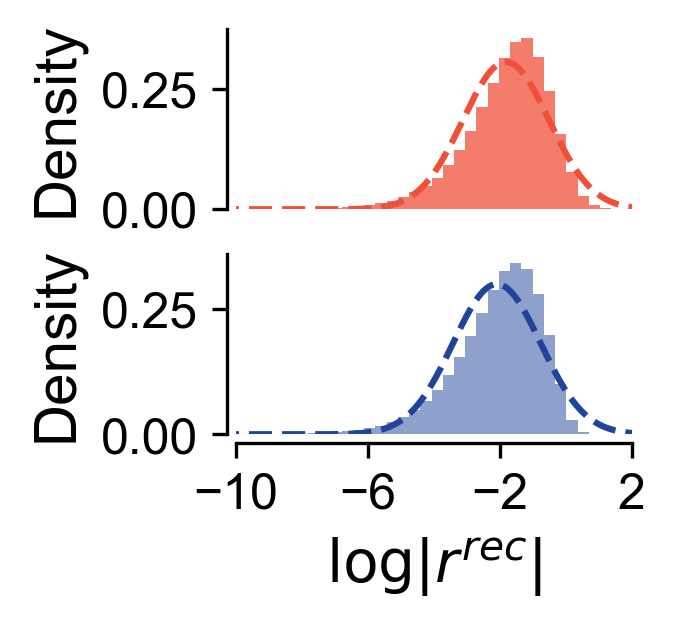

In [18]:
fig = plot_act_hists(eg_all_acts[0], gd_all_acts[0], eg_key="rnn.base_layer.weight_hh", 
                  zero_th=1e-10, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-10, 2, 4),
                       eg_color=eg_exps_dict.c, gd_color=gd_exps_dict.c)  # 1e-5 for log weights

# fig.savefig("figs/S1/1e_ln_weights_hists.pdf", bbox_inches="tight", transparent=True)

In [19]:
import scipy.stats as stats

In [20]:
def ks(eg_arr, gd_arr, zero_th=1e-10, log_weights=True, zscore=True):
    if zero_th is not None:
        gd_arr = gd_arr[gd_arr > zero_th]
        eg_arr = eg_arr[eg_arr > zero_th]
    if log_weights:
        gd_arr = np.log(gd_arr)
        eg_arr = np.log(eg_arr)
    if zscore:
        gd_arr = (gd_arr - gd_arr.mean()) / gd_arr.std()
        eg_arr = (eg_arr - eg_arr.mean()) / eg_arr.std()
    return stats.kstest(eg_arr, gd_arr)

In [49]:
ks_stat_matrix = np.zeros((10, 10))
ks_pval_matrix = np.zeros((10, 10))

for seed_1 in range(5):
    for seed_2 in range(5):
        res = ks(eg_all_acts[seed_1], eg_all_acts[seed_2])
        ks_stat_matrix[seed_1, seed_2], ks_pval_matrix[seed_1, seed_2] = res.statistic, res.pvalue
        
        res = ks(gd_all_acts[seed_1], gd_all_acts[seed_2])
        ks_stat_matrix[seed_1 + 5, seed_2 + 5], ks_pval_matrix[seed_1 + 5, seed_2 + 5] = res.statistic, res.pvalue
        
        res = ks(eg_all_acts[seed_1], gd_all_acts[seed_2])
        ks_stat_matrix[seed_1, seed_2 + 5], ks_pval_matrix[seed_1, seed_2 + 5] = res.statistic, res.pvalue
        
        res = ks(gd_all_acts[seed_1], eg_all_acts[seed_2])
        ks_stat_matrix[seed_1 + 5, seed_2], ks_pval_matrix[seed_1 + 5, seed_2] = res.statistic, res.pvalue

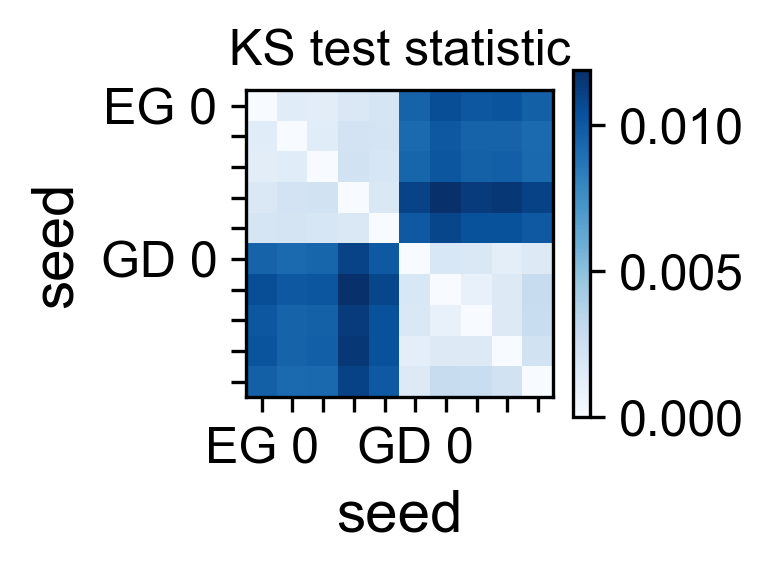

In [45]:
fig = plt.figure(figsize=(1.65,1.5), dpi = 300)
plt.imshow(ks_stat_matrix, cmap="Blues")
plt.colorbar()
plt.xticks(np.arange(10), ['EG 0', *(4 * ['']), 'GD 0', *(4 * [''])])
plt.yticks(np.arange(10), ['EG 0', *(4 * ['']), 'GD 0', *(4 * [''])])
plt.xlabel('seed')
plt.ylabel('seed')
plt.title('KS test statistic')
plt.show()